In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import train_test_split, cross_val_score, RandomizedSearchCV
from sklearn.metrics import mean_absolute_error, r2_score
import pickle
import time

df = pd.read_csv('../data/processed/survey_engineered.csv')

X = df.drop('ConvertedCompYearly', axis=1)
y = df['ConvertedCompYearly']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape}")
print(f"Test set:     {X_test.shape}")

Training set: (34178, 28)
Test set:     (8545, 28)


Testing different n_estimators values...
(This will take ~2 minutes — worth it!)

  n_estimators= 50 → train MAE=$27,012  test MAE=$27,156
  n_estimators=100 → train MAE=$25,742  test MAE=$25,917
  n_estimators=150 → train MAE=$25,226  test MAE=$25,467
  n_estimators=200 → train MAE=$24,940  test MAE=$25,226
  n_estimators=300 → train MAE=$24,606  test MAE=$24,987
  n_estimators=400 → train MAE=$24,419  test MAE=$24,884
  n_estimators=500 → train MAE=$24,286  test MAE=$24,828


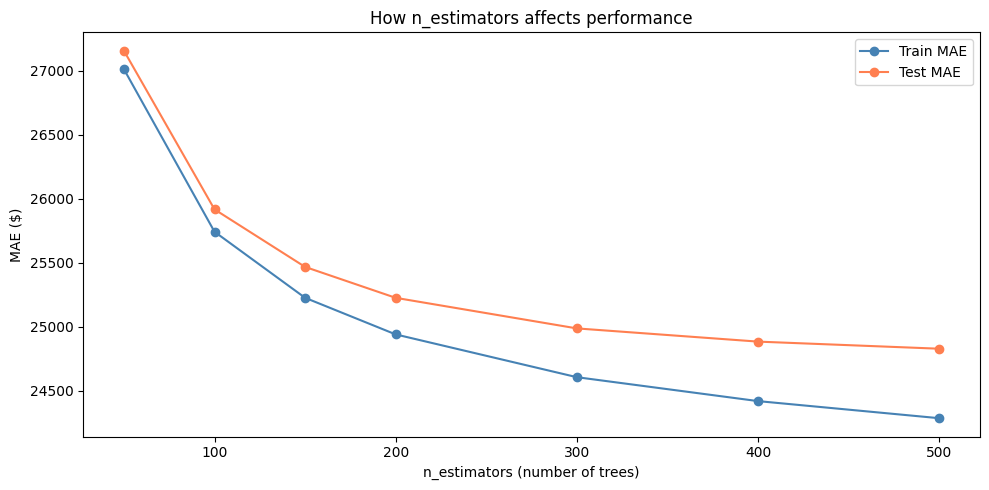

In [3]:
# Let's visualize how n_estimators affects performance
# This teaches you what the hyperparameter actually does!

print("Testing different n_estimators values...")
print("(This will take ~2 minutes — worth it!)\n")

n_estimators_range = [50, 100, 150, 200, 300, 400, 500]
train_scores = []
test_scores = []

for n in n_estimators_range:
    model = GradientBoostingRegressor(
        n_estimators=n,
        learning_rate=0.1,
        random_state=42
    )
    model.fit(X_train, y_train)
    
    train_mae = mean_absolute_error(y_train, model.predict(X_train))
    test_mae  = mean_absolute_error(y_test,  model.predict(X_test))
    
    train_scores.append(train_mae)
    test_scores.append(test_mae)
    print(f"  n_estimators={n:3d} → train MAE=${train_mae:,.0f}  test MAE=${test_mae:,.0f}")

# Plot it!
plt.figure(figsize=(10, 5))
plt.plot(n_estimators_range, train_scores, 'o-', label='Train MAE', color='steelblue')
plt.plot(n_estimators_range, test_scores,  'o-', label='Test MAE',  color='coral')
plt.xlabel('n_estimators (number of trees)')
plt.ylabel('MAE ($)')
plt.title('How n_estimators affects performance')
plt.legend()
plt.tight_layout()
plt.show()

In [4]:
# learning_rate and n_estimators work TOGETHER
# Lower learning_rate = needs MORE trees to compensate
# This is a fundamental tradeoff!

print("Testing learning_rate vs n_estimators tradeoff...\n")

configs = [
    {'learning_rate': 0.3,  'n_estimators': 100},
    {'learning_rate': 0.1,  'n_estimators': 200},   # our current setting
    {'learning_rate': 0.05, 'n_estimators': 400},
    {'learning_rate': 0.01, 'n_estimators': 1000},
]

for config in configs:
    model = GradientBoostingRegressor(
        **config,
        random_state=42
    )
    model.fit(X_train, y_train)
    test_mae = mean_absolute_error(y_test, model.predict(X_test))
    test_r2 = r2_score(y_test, model.predict(X_test))

    print(f"lr={config['learning_rate']:.2f}  trees={config['n_estimators']:4d}"
          f"  →  MAE=${test_mae:,.0f}   R²={test_r2:.3f}")

Testing learning_rate vs n_estimators tradeoff...

lr=0.30  trees= 100  →  MAE=$24,966   R²=0.594
lr=0.10  trees= 200  →  MAE=$25,226   R²=0.586
lr=0.05  trees= 400  →  MAE=$25,240   R²=0.586
lr=0.01  trees=1000  →  MAE=$25,983   R²=0.567


In [5]:
# Define the hyperparameter search space
# These are the ranges RandomizedSearchCV will sample from
param_distributions = {
    'n_estimators':    [100, 200, 300, 400, 500],
    'learning_rate':   [0.01, 0.05, 0.1, 0.15, 0.2],
    'max_depth':       [3, 4, 5, 6, 7],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf':  [1, 2, 4, 8],
    'subsample':       [0.7, 0.8, 0.9, 1.0],
}

print("Hyperparameter search space:")
total_combinations = 1
for param, values in param_distributions.items():
    print(f"  {param}: {values}")
    total_combinations *= len(values)

print(f"\nTotal possible combinations: {total_combinations:,}")
print(f"We'll randomly sample 50 of them — much faster than trying all!")

Hyperparameter search space:
  n_estimators: [100, 200, 300, 400, 500]
  learning_rate: [0.01, 0.05, 0.1, 0.15, 0.2]
  max_depth: [3, 4, 5, 6, 7]
  min_samples_split: [2, 5, 10, 20]
  min_samples_leaf: [1, 2, 4, 8]
  subsample: [0.7, 0.8, 0.9, 1.0]

Total possible combinations: 8,000
We'll randomly sample 50 of them — much faster than trying all!


In [7]:
print("🔍 Starting hyperparameter search...")
print("This will take ~5-10 minutes. Go make tea! ☕\n")

start_time = time.time()

search = RandomizedSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_distributions=param_distributions,
    n_iter=50,               # Try 50 random combinations
    cv=5,                    # 5-fold cross validations
    scoring='neg_mean_absolute_error',  # optimize for MAE
    n_jobs=-1,              # use ALL your CPU cores
    verbose=1,              # print progress
    random_state=42
)

search.fit(X_train, y_train)

elapsed = time.time() - start_time
print(f"\nSearch complete in {elapsed/60:.1f} minutes!")
print(f"\nBest hyperparameters found:")
for param, value in search.best_params_.items():
    print(f"   {param}: {value}")

print(f"\nBest CV MAE: ${-search.best_score_:,.0f}")

🔍 Starting hyperparameter search...
This will take ~5-10 minutes. Go make tea! ☕

Fitting 5 folds for each of 50 candidates, totalling 250 fits



Search complete in 13.7 minutes!

Best hyperparameters found:
   subsample: 0.9
   n_estimators: 500
   min_samples_split: 20
   min_samples_leaf: 8
   max_depth: 5
   learning_rate: 0.05

Best CV MAE: $24,743


In [9]:
# Get the best model from the search
tuned_model = search.best_estimator_

# Evaluate on the test set
tuned_predictions = tuned_model.predict(X_test)
tuned_mae = mean_absolute_error(y_test, tuned_predictions)
tuned_r2 = r2_score(y_test, tuned_predictions)

# Compare with original model
original_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.1,
    random_state=42
)
original_model.fit(X_train, y_train)
original_mae = mean_absolute_error(y_test, original_model.predict(X_test))
original_r2 = r2_score(y_test, original_model.predict(X_test))

print("=" * 50)
print("TUNING RESULTS")
print("=" * 50)
print(f"\n  {'':20s}  {'MAE':>10s}  {'R²':>8s}")
print(f"  {'Original model':20s}  ${original_mae:>9,.0f}  {original_r2:>8.3f}")
print(f"  {'Tuned model':20s}  ${tuned_mae:>9,.0f}  {tuned_r2:>8.3f}")

improvement_mae = original_mae - tuned_mae
improvement_r2 = tuned_r2 - original_r2
print(f"\n  Improvement: MAE ${improvement_mae:,.0f} better  |  R² +{improvement_r2:.3f}")

TUNING RESULTS

                               MAE        R²
  Original model        $   25,226     0.586
  Tuned model           $   24,659     0.601

  Improvement: MAE $566 better  |  R² +0.014


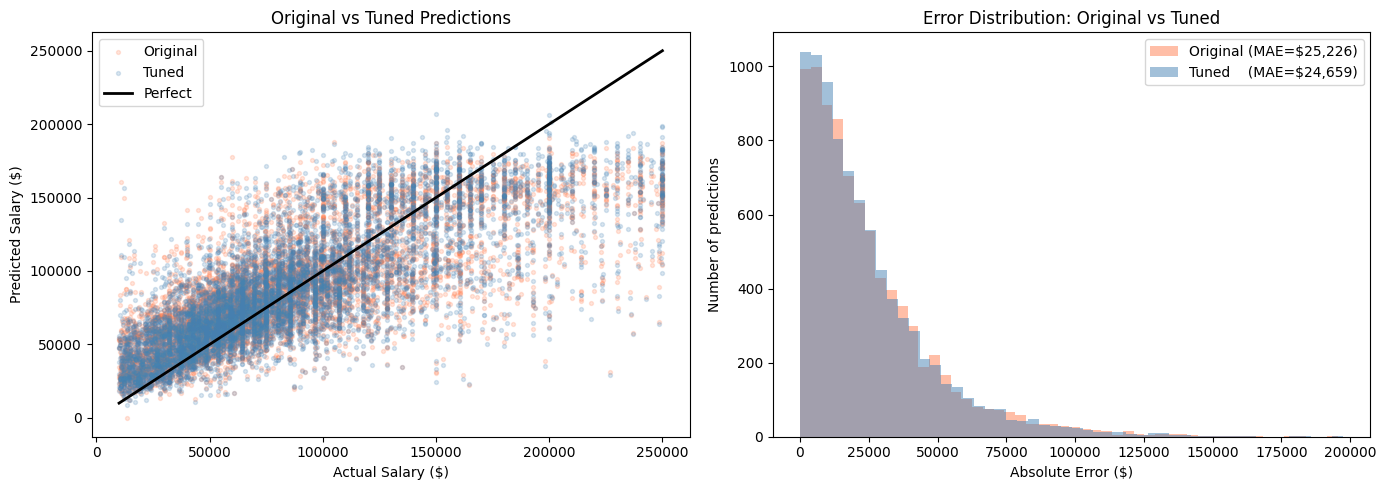

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Predictions comparison
axes[0].scatter(y_test, original_model.predict(X_test), 
                alpha=0.2, s=8, color='coral', label='Original')
axes[0].scatter(y_test, tuned_predictions,
                alpha=0.2, s=8, color='steelblue', label='Tuned')
axes[0].plot([10000, 250000], [10000, 250000], 'k-', linewidth=2, label='Perfect')
axes[0].set_xlabel('Actual Salary ($)')
axes[0].set_ylabel('Predicted Salary ($)')
axes[0].set_title('Original vs Tuned Predictions')
axes[0].legend()

# Plot 2: Error distribution
original_errors = np.abs(original_model.predict(X_test) - y_test)
tuned_errors    = np.abs(tuned_predictions - y_test)

axes[1].hist(original_errors, bins=50, alpha=0.5, color='coral',   label=f'Original (MAE=${original_mae:,.0f})')
axes[1].hist(tuned_errors,    bins=50, alpha=0.5, color='steelblue', label=f'Tuned    (MAE=${tuned_mae:,.0f})')
axes[1].set_xlabel('Absolute Error ($)')
axes[1].set_ylabel('Number of predictions')
axes[1].set_title('Error Distribution: Original vs Tuned')
axes[1].legend()

plt.tight_layout()
plt.show()

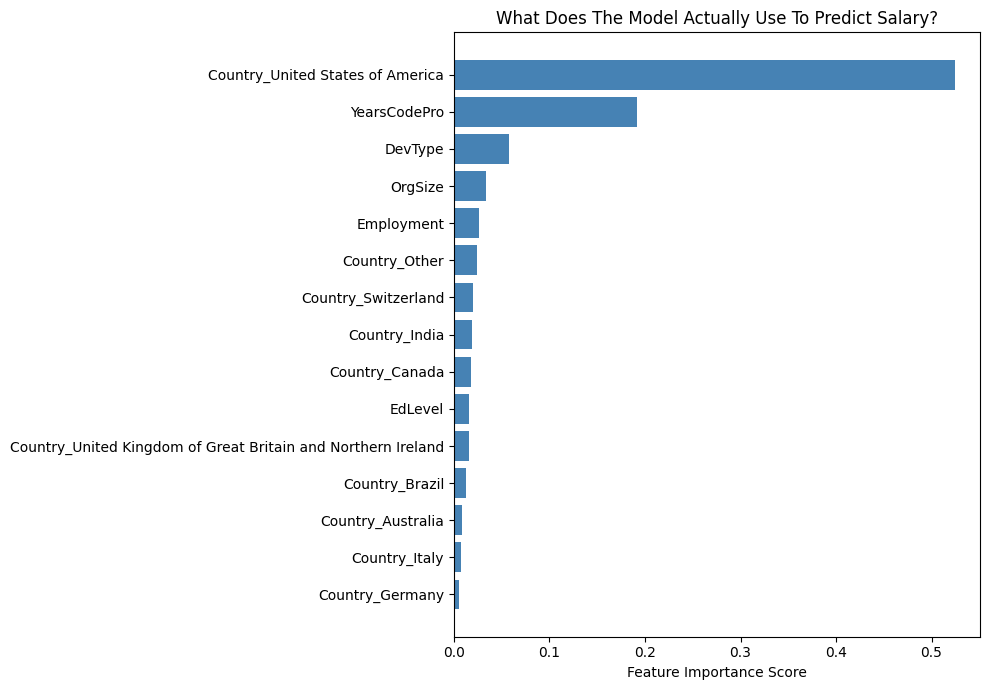


Top 5 most important features:
  Country_United States of America   : 0.5245
  YearsCodePro                       : 0.1915
  DevType                            : 0.0578
  OrgSize                            : 0.0337
  Employment                         : 0.0264


In [11]:
# Get feature importance from the tuned model
feature_importance = pd.DataFrame({
    'feature': X.columns,
    'importance': tuned_model.feature_importances_
}).sort_values('importance', ascending=True)

# Plot top 15 most important features
top_features = feature_importance.tail(15)

plt.figure(figsize=(10, 7))
plt.barh(top_features['feature'], top_features['importance'], color='steelblue')
plt.xlabel('Feature Importance Score')
plt.title('What Does The Model Actually Use To Predict Salary?')
plt.tight_layout()
plt.show()

print("\nTop 5 most important features:")
for _, row in feature_importance.tail(5).iloc[::-1].iterrows():
    print(f"  {row['feature']:35s}: {row['importance']:.4f}")